# Simulate Cost Notebook

Run the cells in order. This notebook stores the raw simulated data and the summary results for every scenario.

In [1]:
import os
import random

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import minimize_scalar

## Parameters And Storage

Paper notation used here:

- `alpha` = demand uncertainty
- `beta` = estimate uncertainty

This cell creates the main objects you can work with later:

- `scenario_data`: raw `D` and `E` for each scenario
- `summary_rows`: summary numbers before turning them into a table
- `scenario_table`: tidy table created later
- `total_cost_matrix`: 4x4 matrix for the heatmap
- `estimate_samples_matrix`: 4x4 stored `E` samples for the histograms

This version uses a smaller demand-uncertainty grid and a larger estimate-uncertainty grid so forecast uncertainty has a clearer impact on the demand-based cost results.

In [2]:
# Parameters
ITERATIONS = 50000
SHORTFALL_COST = 10.0  # c^s

# In the paper notation:
# alpha = demand uncertainty
# beta = estimate uncertainty
DEMAND_UNCERTAINTY_LEVELS = {
    "none": 0.0,
    "low": 0.1,
    "med": 0.2,
    "high": 0.3,
}
ESTIMATE_UNCERTAINTY_LEVELS = {
    "none": 0.0,
    "low": 0.15,
    "med": 0.3,
    "high": 0.45,
}
SEED = 123

demand_levels = list(DEMAND_UNCERTAINTY_LEVELS.keys())
estimate_levels = list(ESTIMATE_UNCERTAINTY_LEVELS.keys())
total_cost_matrix = [[0.0 for _ in estimate_levels] for _ in demand_levels]
estimate_samples_matrix = [[None for _ in estimate_levels] for _ in demand_levels]

# Main storage objects
scenario_data = {}
summary_rows = []

os.makedirs("Figures", exist_ok=True)

## Run Simulation And Store Everything

This cell simulates `D` and `E`, optimizes `S`, and stores both the raw samples and the expected costs.

In the equations from the paper:

- `D ~ LogNormal(-alpha^2 / 2, alpha^2)`
- `E = D * LogNormal(-beta^2 / 2, beta^2)`

In [3]:
header = (
    f"{'Demand':<6} {'Estimate':<8} "
    f"{'Exp inv cost':>14} {'Exp short cost':>16} {'Exp total cost':>16}"
)
print(header)
print("-" * len(header))

scenario_data.clear()
summary_rows.clear()
total_cost_matrix = [[0.0 for _ in estimate_levels] for _ in demand_levels]
estimate_samples_matrix = [[None for _ in estimate_levels] for _ in demand_levels]

for demand_label, demand_sigma in DEMAND_UNCERTAINTY_LEVELS.items():
    for estimate_label, estimate_sigma in ESTIMATE_UNCERTAINTY_LEVELS.items():
        rng = random.Random(f"{SEED}:{demand_label}:{estimate_label}")

        alpha = demand_sigma
        beta = estimate_sigma

        D = []
        E = []

        for _ in range(ITERATIONS):
            if alpha == 0:
                demand = 1.0
            else:
                demand_mu = -0.5 * alpha * alpha
                demand = rng.lognormvariate(demand_mu, alpha)

            if beta == 0:
                estimate_noise = 1.0
            else:
                estimate_mu = -0.5 * beta * beta
                estimate_noise = rng.lognormvariate(estimate_mu, beta)

            estimate = demand * estimate_noise

            D.append(demand)
            E.append(estimate)

        result = minimize_scalar(
            lambda S: S + SHORTFALL_COST * sum(max(e - S, 0.0) for e in E) / ITERATIONS,
            bounds=(0.0, max(E)),
            method="bounded",
        )

        S = result.x
        expected_investment_cost = S
        expected_shortfall_cost = SHORTFALL_COST * sum(max(e - S, 0.0) for e in E) / ITERATIONS
        expected_total_cost = expected_investment_cost + expected_shortfall_cost
        expected_demand_shortfall_cost = SHORTFALL_COST * sum(max(d - S, 0.0) for d in D) / ITERATIONS
        expected_demand_total_cost = expected_investment_cost + expected_demand_shortfall_cost

        row_index = demand_levels.index(demand_label)
        col_index = estimate_levels.index(estimate_label)
        total_cost_matrix[row_index][col_index] = expected_total_cost
        estimate_samples_matrix[row_index][col_index] = E.copy()

        scenario_data[(demand_label, estimate_label)] = {
            "alpha": alpha,
            "beta": beta,
            "D": D.copy(),
            "E": E.copy(),
            "optimal_S": S,
            "expected_investment_cost": expected_investment_cost,
            "expected_shortfall_cost": expected_shortfall_cost,
            "expected_total_cost": expected_total_cost,
            "expected_demand_shortfall_cost": expected_demand_shortfall_cost,
            "expected_demand_total_cost": expected_demand_total_cost,
        }

        summary_rows.append({
            "demand_level": demand_label,
            "estimate_level": estimate_label,
            "alpha": alpha,
            "beta": beta,
            "optimal_S": S,
            "expected_investment_cost": expected_investment_cost,
            "expected_shortfall_cost": expected_shortfall_cost,
            "expected_total_cost": expected_total_cost,
            "expected_demand_shortfall_cost": expected_demand_shortfall_cost,
            "expected_demand_total_cost": expected_demand_total_cost,
        })

        print(
            f"{demand_label:<6} "
            f"{estimate_label:<8} "
            f"{expected_investment_cost:>14.4f} "
            f"{expected_shortfall_cost:>16.4f} "
            f"{expected_total_cost:>16.4f}"
        )

Demand Estimate   Exp inv cost   Exp short cost   Exp total cost
----------------------------------------------------------------
none   none             1.0000           0.0001           1.0001
none   low              1.1987           0.0913           1.2899
none   med              1.4013           0.2315           1.6329
none   high             1.6006           0.4175           2.0181
low    none             1.1303           0.0554           1.1857
low    low              1.2405           0.1162           1.3567
low    med              1.4228           0.2424           1.6652
low    high             1.6254           0.4409           2.0662
med    none             1.2697           0.1330           1.4027
med    low              1.3357           0.1766           1.5123
med    med              1.4911           0.2923           1.7834
med    high             1.6635           0.4787           2.1422
high   none             1.4048           0.2225           1.6273
high   low              1

## Inspect Stored Data

These cells let you play with the stored results directly.

In [4]:
scenario_table = pd.DataFrame(summary_rows)
scenario_table

,demand_level,estimate_level,alpha,beta,optimal_S,expected_investment_cost,expected_shortfall_cost,expected_total_cost,expected_demand_shortfall_cost,expected_demand_total_cost
0,none,none,0.0,0.00,0.999994,0.999994,0.000060,1.000054,0.000060,1.000054
1,none,low,0.0,0.15,1.198651,1.198651,0.091251,1.289902,0.000000,1.198651
2,none,med,0.0,0.30,1.401306,1.401306,0.231546,1.632852,0.000000,1.401306
3,none,high,0.0,0.45,1.600607,1.600607,0.417514,2.018121,0.000000,1.600607
4,low,none,0.1,0.00,1.130290,1.130290,0.055394,1.185684,0.055394,1.185684
5,low,low,0.1,0.15,1.240507,1.240507,0.116193,1.356700,0.006413,1.246920
6,low,med,0.1,0.30,1.422801,1.422801,0.242408,1.665208,0.000093,1.422894
7,low,high,0.1,0.45,1.625359,1.625359,0.440879,2.066238,0.000000,1.625359
8,med,none,0.2,0.00,1.269686,1.269686,0.133026,1.402712,0.133026,1.402712
9,med,low,0.2,0.15,1.335671,1.335671,0.176599,1.512271,0.075023,1.410694


In [5]:
list(scenario_data.keys())

[('none', 'none'),
 ('none', 'low'),
 ('none', 'med'),
 ('none', 'high'),
 ('low', 'none'),
 ('low', 'low'),
 ('low', 'med'),
 ('low', 'high'),
 ('med', 'none'),
 ('med', 'low'),
 ('med', 'med'),
 ('med', 'high'),
 ('high', 'none'),
 ('high', 'low'),
 ('high', 'med'),
 ('high', 'high')]

In [6]:
scenario_data[("low", "high")]

{'alpha': 0.1,
 'beta': 0.45,
 'D': [0.8947961785324916,
  0.9559802434494198,
  1.1355044939381713,
  0.9610895444962984,
  1.1507432367635402,
  1.169194140801052,
  0.8874352056708656,
  0.9776590353371184,
  1.0440204134480309,
  0.8270419619984145,
  1.1004500879904624,
  1.1070673000294635,
  1.244727143030123,
  1.010161748620311,
  0.9866849478902313,
  0.8846535766839276,
  1.0716130750012889,
  0.8721630303843407,
  1.1252817533363366,
  1.0204376701120021,
  1.2819470357192326,
  0.9233047220699249,
  0.8789318289359483,
  1.08977834702887,
  0.9687846055855442,
  0.9558079998347115,
  0.9394843006798191,
  1.005833003404385,
  0.8808356678212605,
  1.0493017545047272,
  0.9554984581971075,
  0.8904834086882208,
  0.9122736379734138,
  1.1120185152228703,
  1.0025117060803084,
  1.0222935095293593,
  1.0725173150790048,
  0.9349839357027058,
  0.9336100189338066,
  1.0354442501716397,
  0.9400109418943673,
  1.0035346805956706,
  1.0066569362059454,
  0.9115100238636138,
  1

In [7]:
scenario_data[("low", "high")]["D"][:10], scenario_data[("low", "high")]["E"][:10]

([0.8947961785324916,
  0.9559802434494198,
  1.1355044939381713,
  0.9610895444962984,
  1.1507432367635402,
  1.169194140801052,
  0.8874352056708656,
  0.9776590353371184,
  1.0440204134480309,
  0.8270419619984145],
 [1.139527059799628,
  1.867700322654891,
  2.8509139865484916,
  0.6498866116513466,
  0.5549970767100078,
  0.5222508876679639,
  2.050983158355862,
  0.9042599549859763,
  1.4592681440432396,
  0.8577008634189833])

## Plots

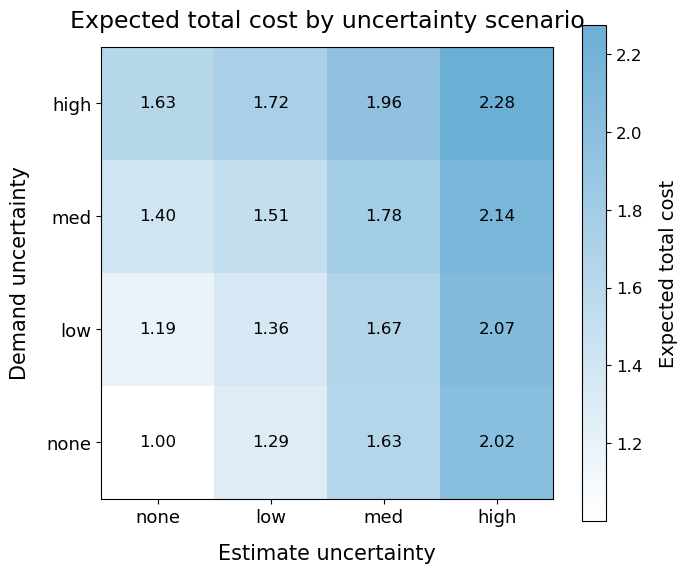

In [8]:
cmap = LinearSegmentedColormap.from_list("white_to_blue", ["#ffffff", "#6baed6"])

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(total_cost_matrix, origin="lower", cmap=cmap)

ax.set_xticks(range(len(estimate_levels)))
ax.set_yticks(range(len(demand_levels)))
ax.set_xticklabels(estimate_levels)
ax.set_yticklabels(demand_levels)
ax.set_xlabel("Estimate uncertainty", fontsize=15, color="black", labelpad=12)
ax.set_ylabel("Demand uncertainty", fontsize=15, color="black", labelpad=12)
ax.set_title("Expected total cost by uncertainty scenario", fontsize=17, color="black", pad=14)
ax.tick_params(axis="both", labelsize=13, colors="black")

for row_index in range(len(demand_levels)):
    for col_index in range(len(estimate_levels)):
        value = total_cost_matrix[row_index][col_index]
        ax.text(col_index, row_index, f"{value:.2f}", ha="center", va="center", fontsize=12, color="black")

colorbar = plt.colorbar(image, ax=ax)
colorbar.set_label("Expected total cost", fontsize=14, color="black", labelpad=12)
colorbar.ax.tick_params(labelsize=12, colors="black")

plt.tight_layout()
plt.savefig("../Figures/expected_total_cost_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

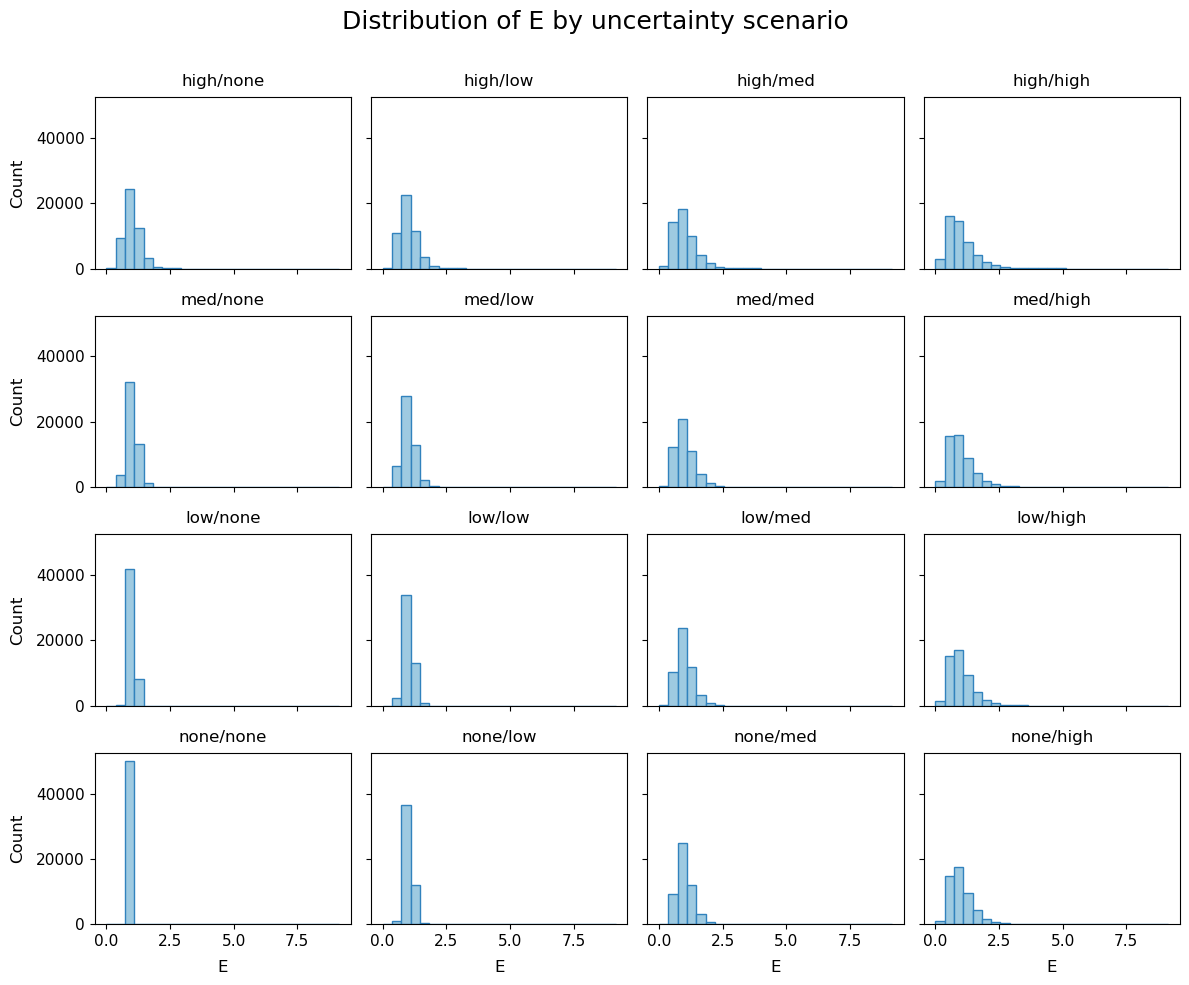

In [9]:
all_E_values = []
for row in estimate_samples_matrix:
    for samples in row:
        all_E_values.extend(samples)

global_max_E = max(all_E_values)

fig, axes = plt.subplots(len(demand_levels), len(estimate_levels), figsize=(12, 10), sharex=True, sharey=True)

for row_index in range(len(demand_levels)):
    for col_index in range(len(estimate_levels)):
        plot_row = len(demand_levels) - 1 - row_index
        ax = axes[plot_row][col_index]
        E_values = estimate_samples_matrix[row_index][col_index]

        ax.hist(
            E_values,
            bins=25,
            range=(0.0, global_max_E),
            color="#9ecae1",
            edgecolor="#3182bd",
        )
        ax.set_title(f"{demand_levels[row_index]}/{estimate_levels[col_index]}", fontsize=12, color="black", pad=8)

        if plot_row == len(demand_levels) - 1:
            ax.set_xlabel("E", fontsize=12, color="black", labelpad=8)
        if col_index == 0:
            ax.set_ylabel("Count", fontsize=12, color="black", labelpad=8)
        ax.tick_params(axis="both", labelsize=11, colors="black")

fig.suptitle("Distribution of E by uncertainty scenario", fontsize=18, color="black")
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.savefig("../Figures/estimate_histogram_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Estimate-Based Cost Composition Matrix

This plot colors each scenario by expected total cost and also shows the expected investment cost and estimate-based shortfall cost, both as values and as shares of the total.

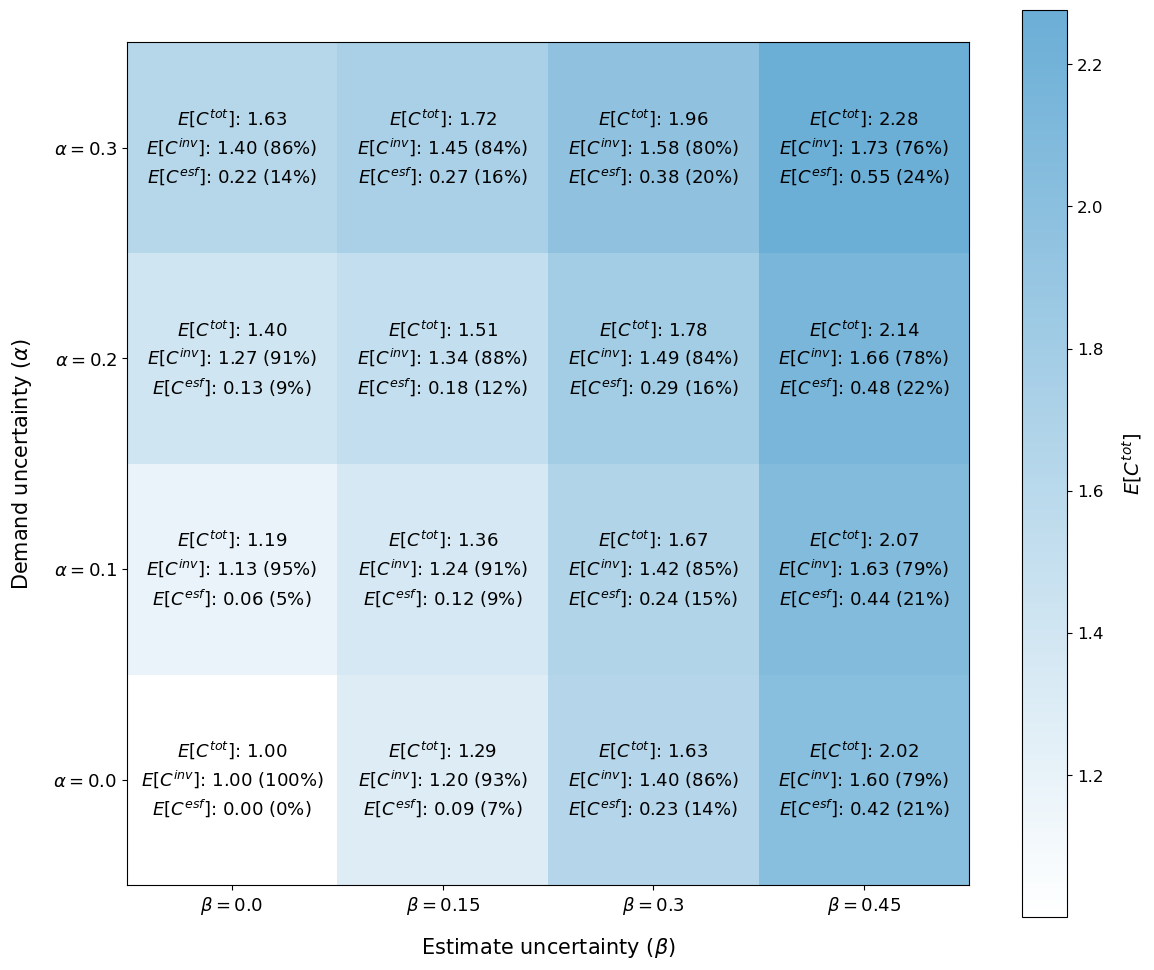

In [10]:
total_cost_plot = [[0.0 for _ in estimate_levels] for _ in demand_levels]
investment_cost_plot = [[0.0 for _ in estimate_levels] for _ in demand_levels]
shortfall_cost_plot = [[0.0 for _ in estimate_levels] for _ in demand_levels]

for _, row in scenario_table.iterrows():
    row_index = demand_levels.index(row["demand_level"])
    col_index = estimate_levels.index(row["estimate_level"])
    total_cost_plot[row_index][col_index] = row["expected_total_cost"]
    investment_cost_plot[row_index][col_index] = row["expected_investment_cost"]
    shortfall_cost_plot[row_index][col_index] = row["expected_shortfall_cost"]

cmap = LinearSegmentedColormap.from_list("white_to_blue", ["#ffffff", "#6baed6"])

beta_tick_labels = [rf"$\beta = {value}$" for value in ESTIMATE_UNCERTAINTY_LEVELS.values()]
alpha_tick_labels = [rf"$\alpha = {value}$" for value in DEMAND_UNCERTAINTY_LEVELS.values()]

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(total_cost_plot, origin="lower", cmap=cmap)

ax.set_xticks(range(len(estimate_levels)))
ax.set_yticks(range(len(demand_levels)))
ax.set_xticklabels(beta_tick_labels)
ax.set_yticklabels(alpha_tick_labels)
ax.set_xlabel(r"Estimate uncertainty ($\beta$)", fontsize=15, color="black", labelpad=14)
ax.set_ylabel(r"Demand uncertainty ($\alpha$)", fontsize=15, color="black", labelpad=14)
ax.tick_params(axis="both", labelsize=13, colors="black")

for row_index in range(len(demand_levels)):
    for col_index in range(len(estimate_levels)):
        total_value = total_cost_plot[row_index][col_index]
        investment_value = investment_cost_plot[row_index][col_index]
        shortfall_value = shortfall_cost_plot[row_index][col_index]
        investment_share = 100 * investment_value / total_value
        shortfall_share = 100 * shortfall_value / total_value

        label = (
            f"$E[C^{{tot}}]$: {total_value:.2f}\n"
            f"$E[C^{{inv}}]$: {investment_value:.2f} ({investment_share:.0f}%)\n"
            f"$E[C^{{esf}}]$: {shortfall_value:.2f} ({shortfall_share:.0f}%)"
        )

        ax.text(
            col_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=13,
            color="black",
            linespacing=1.4,
        )

colorbar = plt.colorbar(image, ax=ax)
colorbar.set_label(r"$E[C^{tot}]$", fontsize=14, color="black", labelpad=12)
colorbar.ax.tick_params(labelsize=12, colors="black")

plt.tight_layout()
plt.savefig("../Figures/expected_cost_breakdown_matrix.pdf", bbox_inches="tight")
plt.show()

## Demand-Based Cost Composition Matrix

This plot has the same style, but it uses the real demand shortfall cost
$E[C^{dsf}] = c^s (D - S)^+$
instead of the estimate-based shortfall cost.

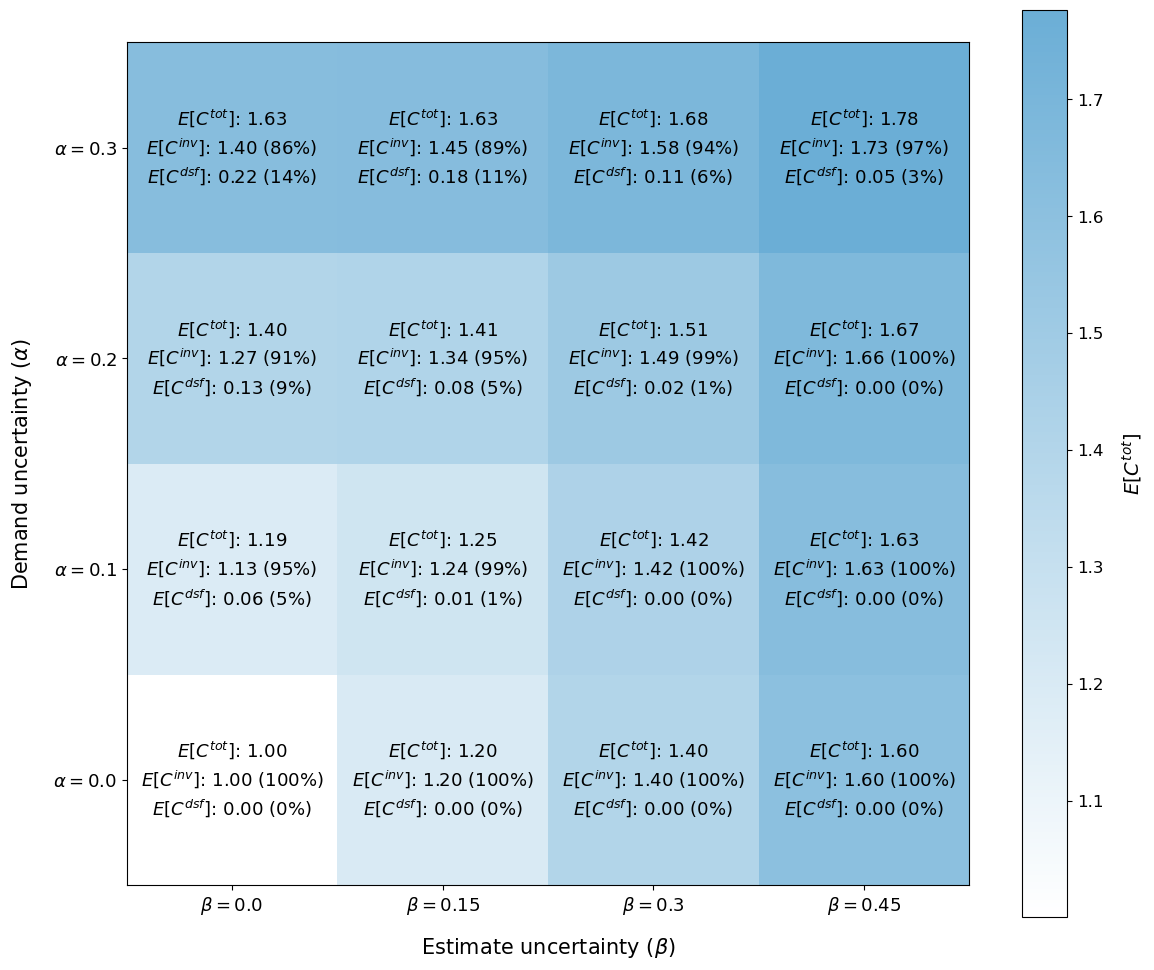

In [11]:
demand_total_cost_plot = [[0.0 for _ in estimate_levels] for _ in demand_levels]
investment_cost_plot = [[0.0 for _ in estimate_levels] for _ in demand_levels]
demand_shortfall_cost_plot = [[0.0 for _ in estimate_levels] for _ in demand_levels]

for _, row in scenario_table.iterrows():
    row_index = demand_levels.index(row["demand_level"])
    col_index = estimate_levels.index(row["estimate_level"])
    demand_total_cost_plot[row_index][col_index] = row["expected_demand_total_cost"]
    investment_cost_plot[row_index][col_index] = row["expected_investment_cost"]
    demand_shortfall_cost_plot[row_index][col_index] = row["expected_demand_shortfall_cost"]

cmap = LinearSegmentedColormap.from_list("white_to_blue", ["#ffffff", "#6baed6"])

beta_tick_labels = [rf"$\beta = {value}$" for value in ESTIMATE_UNCERTAINTY_LEVELS.values()]
alpha_tick_labels = [rf"$\alpha = {value}$" for value in DEMAND_UNCERTAINTY_LEVELS.values()]

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(demand_total_cost_plot, origin="lower", cmap=cmap)

ax.set_xticks(range(len(estimate_levels)))
ax.set_yticks(range(len(demand_levels)))
ax.set_xticklabels(beta_tick_labels)
ax.set_yticklabels(alpha_tick_labels)
ax.set_xlabel(r"Estimate uncertainty ($\beta$)", fontsize=15, color="black", labelpad=14)
ax.set_ylabel(r"Demand uncertainty ($\alpha$)", fontsize=15, color="black", labelpad=14)
ax.tick_params(axis="both", labelsize=13, colors="black")

for row_index in range(len(demand_levels)):
    for col_index in range(len(estimate_levels)):
        total_value = demand_total_cost_plot[row_index][col_index]
        investment_value = investment_cost_plot[row_index][col_index]
        demand_shortfall_value = demand_shortfall_cost_plot[row_index][col_index]
        investment_share = 100 * investment_value / total_value
        demand_shortfall_share = 100 * demand_shortfall_value / total_value

        label = (
            f"$E[C^{{tot}}]$: {total_value:.2f}\n"
            f"$E[C^{{inv}}]$: {investment_value:.2f} ({investment_share:.0f}%)\n"
            f"$E[C^{{dsf}}]$: {demand_shortfall_value:.2f} ({demand_shortfall_share:.0f}%)"
        )

        ax.text(
            col_index,
            row_index,
            label,
            ha="center",
            va="center",
            fontsize=13,
            color="black",
            linespacing=1.4,
        )

colorbar = plt.colorbar(image, ax=ax)
colorbar.set_label(r"$E[C^{tot}]$", fontsize=14, color="black", labelpad=12)
colorbar.ax.tick_params(labelsize=12, colors="black")

plt.tight_layout()
plt.savefig("../Figures/expected_demand_shortfall_breakdown_matrix.pdf", bbox_inches="tight")
plt.show()